/home/lbraun/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
[ WARN:0@0.286] global loadsave.cpp:278 findDecoder imread_('obj/foto_10.png'): can't open/read file: check file path/integrity


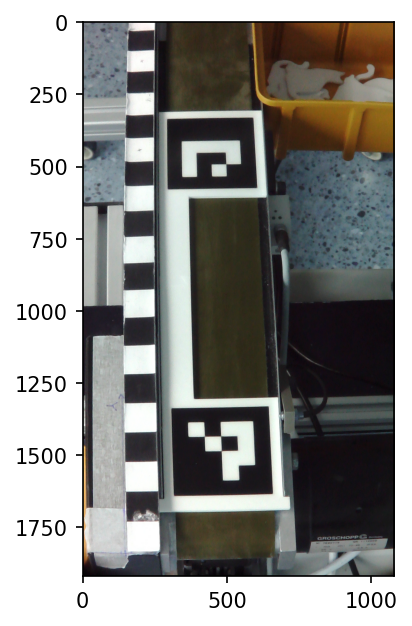

In [2]:
import cv2 as cv
from cv2 import aruco
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)
parameters = aruco.DetectorParameters()
detector = aruco.ArucoDetector(aruco_dict, parameters)

img_aruco = cv.imread('aruco_pic/aruco_0.png')
img_obj = cv.imread('obj/foto_10.png')

img_aruco_rotated = cv.rotate(img_aruco,2)
img_obj_rotated = cv.rotate(img_obj,2)

SRC_COORDS = (np.array([[[ 0.,  0.],  [60., 0.],   [60., 60.],  [ 0.,60.], 
                                [ 0., 222.], [60., 222.], [60., 282.], [ 0., 282.]]], dtype= np.float32))

plt.imshow(img_aruco_rotated)

import cv2
import matplotlib.pyplot as plt

Coordinates that you want to Perspective Transform
pts1 = np.float32([[219,209],[612,8],[380,493],[785,271]])

Size of the Transformed Image
pts2 = np.float32([[0,0],[500,0],[0,400],[500,400]])
for val in pt1:
    cv2.circle(paper,(val[0],val[1]),5,(0,255,0),-1)
M = cv2.getPerspectiveTransform(pt1,pts2)
dst = cv2.warpPerspective(paper,M,(500,400))
plt.imshow(dst)

In [10]:
corners, ids, rejected = detector.detectMarkers(img_aruco_rotated)
dstPoints = np.concatenate(corners, axis=1)

H, _ = cv.findHomography(srcPoints=SRC_COORDS, dstPoints=dstPoints, method=0)
H_inv = np.linalg.inv(H)

(np.float64(-0.5), np.float64(1079.5), np.float64(1919.5), np.float64(-0.5))

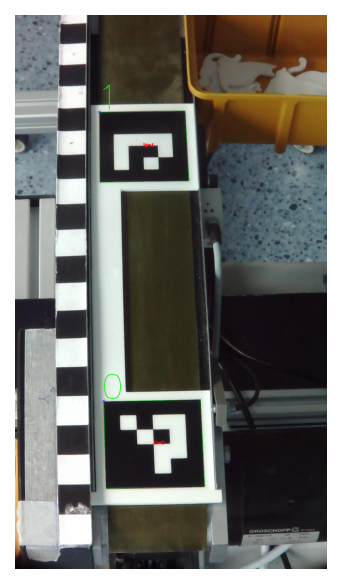

In [17]:
# Marker anzeichnen

if len(ids) > 0:
    img_markers = img_aruco_rotated.copy()
    aruco.drawDetectedMarkers(img_markers, corners, ids)
    
    for i, corner in enumerate(corners):
        top_left = corner[0][0]  # corner[marker][punkt][x/y]
        cv.putText(img_markers, str(ids[i][0]),
                   (int(top_left[0]) - 10, int(top_left[1]) - 10),
                   cv.FONT_HERSHEY_SIMPLEX, 4, (0, 255, 0), 2)
    
    #cv.imshow("Detected Markers", img_markers)
    #cv.waitKey(0)
    #cv.destroyAllWindows()
else:
    print("Keine Marker erkannt!")

fig = plt.imshow(img_markers, cmap = 'gray', vmin=0, vmax=255)
plt.axis('off')

In [ ]:
# pixel in Bild zu welt
for
    

# versatz

# welt in pixel

In [13]:

pts1 = np.float32([
    corners[1][0][0],  # oben-links
    corners[1][0][1],  # oben-rechts
    corners[0][0][3],  # unten-links
    corners[0][0][2],  # unten-rechts
])
pts1

array([[ 292.,  339.],
       [ 589.,  335.],
       [ 314., 1640.],
       [ 656., 1636.]], dtype=float32)

In [14]:
pts2 = np.float32([
    [0,   0],
    [1080, 0],
    [0,   1920],
    [1080, 1920],
])

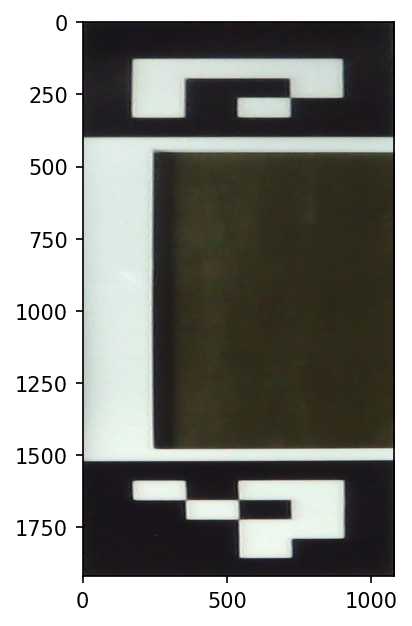

In [15]:
M = cv.getPerspectiveTransform(pts1, pts2)
dst = cv.warpPerspective(img_aruco_rotated,M,(1080,1920))
plt.imshow(dst)
